<a href="https://colab.research.google.com/github/kamij45/CNN-Binary-Image-Classifier/blob/main/CNN_for_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
!ls -lh /content

total 250M
-rw-r--r-- 1 root root 250M Oct  7 00:22 'Cats vs Dogs.zip'
drwxr-xr-x 1 root root 4.0K Sep 30 13:28  sample_data


In [3]:
!unzip -q "/content/Cats vs Dogs.zip" -d /content/data

In [4]:
import os
for root, dirs, files in os.walk("/content/data"):
  print(root, len(files))

/content/data 0
/content/data/cat-dog 5
/content/data/cat-dog/test 0
/content/data/cat-dog/test/cat 505
/content/data/cat-dog/test/dog 521
/content/data/cat-dog/train 0
/content/data/cat-dog/train/cat 4045
/content/data/cat-dog/train/dog 4177
/content/data/cat-dog/dev 0
/content/data/cat-dog/dev/cat 505
/content/data/cat-dog/dev/dog 521


In [5]:
base = "/content/data/cat-dog"

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base}/train", image_size=(128, 128), batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base}/dev", image_size=(128, 128), batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{base}/test", image_size=(128, 128), batch_size=32, shuffle=False
)

print(train_ds.class_names)

Found 8222 files belonging to 2 classes.
Found 1026 files belonging to 2 classes.
Found 1026 files belonging to 2 classes.
['cat', 'dog']


(128, 128, 3)


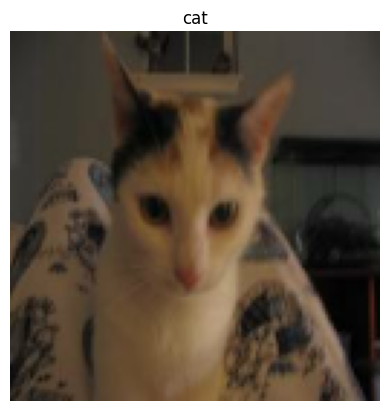

In [6]:
class_names = train_ds.class_names

for images, labels in train_ds.take(1):
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0]])
  plt.axis("off")
  print(images[0].shape)

In [7]:
cnn_model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [8]:
c_history = cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
c_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.5944 - loss: 0.6633 - val_accuracy: 0.6754 - val_loss: 0.5920
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6784 - loss: 0.5944 - val_accuracy: 0.6842 - val_loss: 0.5924
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7379 - loss: 0.5271 - val_accuracy: 0.7534 - val_loss: 0.5093
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7795 - loss: 0.4634 - val_accuracy: 0.7485 - val_loss: 0.5184
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8027 - loss: 0.4228 - val_accuracy: 0.7953 - val_loss: 0.4623
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8370 - loss: 0.3586 - val_accuracy: 0.7865 - val_loss: 0.4767
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8700 - loss: 0.3001 - val_accuracy: 0.7563 - val_loss: 0.6163
Epoch 8/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.8944 - loss: 0.2461 - val_a

In [10]:
test_loss, test_acc = cnn_model.evaluate(test_ds)
print("Test_loss:", test_loss)
print("Test_accuracy:", test_acc)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7973 - loss: 0.6453
Test_loss: 0.6453381180763245
Test_accuracy: 0.7972709536552429
